# Import Modules

In [1]:
import importlib
import os
import sys

import numpy as np
import pandas as pd
import polars as pl

In [2]:
os.chdir("../")
sys.path.insert(0, os.getcwd())

In [3]:
from morai.experience import charters, experience, tables
from morai.forecast import graduation, metrics, preprocessors
from morai.utils import custom_logger, helpers

In [4]:
logger = custom_logger.setup_logging(__name__)

In [5]:
# update log level if wanting more logging
custom_logger.set_log_level("INFO")

In [6]:
pd.options.display.float_format = "{:,.2f}".format

In [7]:
# default is "plotly_mimetype+notebook", however that takes up space.
# "plotly_mimetype+notebook_connected" seems to save space
import plotly.io as pio

pio.renderers.default = "plotly_mimetype+notebook_connected"

# Data

In [8]:
pl_parquet_path = r"files/dataset/full_mortality_grouped_1223.parquet"

In [9]:
# reading in the dataset
# `enable_string_cache` helps with categorical type values
pl.enable_string_cache()
lzdf = pl.scan_parquet(
    pl_parquet_path,
)

In [10]:
initial_row_count = lzdf.select(pl.len()).collect().item()
print(
    f"row count: {initial_row_count:,} \n"
    f"exposures: {lzdf.select([pl.col('amount_exposed').sum()]).collect()[0,0]:,}"
)

row count: 24,440,305 
exposures: 145,636,977,898,544.53


In [11]:
grouped_df = lzdf.collect()

In [12]:
grouped_df = grouped_df.to_pandas()

ArrowMemoryError: malloc of size 586567360 failed

In [ ]:
grouped_df["observation_year"].unique()

# Preparing Data

## Filters

In [14]:
grouped_df = grouped_df[
    (grouped_df["attained_age"] <= 95)
    & (grouped_df["issue_age"] >= 30)
    & (grouped_df["issue_age"] <= 80)
    & (
        grouped_df["face_amount_band"].isin(
            [
                "05: 100,000 - 249,999",
                "06: 250,000 - 499,999",
                "07: 500,000 - 999,999",
                "08: 1,000,000 - 2,499,999",
                "09: 2,500,000 - 4,999,999",
                "10: 5,000,000 - 9,999,999",
                "11: 10,000,000+",
            ]
        )
    )
    # & (grouped_df["observation_year"] >= 2018)
]

## Add Mortality Table

In [15]:
grouped_df = tables.map_rates(
    df=grouped_df,
    rate="vbt15_ult",
)

 2025-12-08 23:36:38 | morai.experience.tables | INFO     | mapping rate: 'qx_vbt15_ult' with format: 'csv' 
 2025-12-08 23:36:38 | morai.experience.tables | WARNING  | rate: 'qx_vbt15_ult' already exists in the DataFrame. Overwriting the rate. 
 2025-12-08 23:36:39 | morai.experience.tables | INFO     | the mapped rates are based on the following keys: ['attained_age', 'sex', 'smoker_status'] 


In [16]:
grouped_df = experience.calc_qx_exp_ae(
    model_data=grouped_df,
    predictions=grouped_df["qx_vbt15_ult"],
    model_name="vbt15_ult",
    exposure_col="amount_exposed",
    actual_col="death_claim_amount",
)

# whl 2d

In [17]:
grouped_df["binned_issue_age"] = preprocessors.bin_feature(grouped_df["issue_age"], 5)

In [18]:
fig = charters.chart(
    df=grouped_df,
    x_axis="duration",
    y_axis="ratio",
    color="binned_issue_age",
    type="line",
    numerator="death_claim_amount",
    denominator="exp_amt_vbt15_ult",
    display=False,
)

 2025-12-08 23:36:53 | morai.experience.charters | INFO     | Calculating ratio using [death_claim_amount] and [exp_amt_vbt15_ult] 
['death_claim_amount', 'exp_amt_vbt15_ult']


In [19]:
rates_pivot = fig.pivot_table(
    index="duration",
    columns="binned_issue_age",
    values="ratio",
    aggfunc="mean",
    observed=False,
)

weights_pivot = fig.pivot_table(
    index="duration",
    columns="binned_issue_age",
    values="exp_amt_vbt15_ult",
    aggfunc="sum",
    observed=False,
)

rates_pivot.fillna(0, inplace=True)
weights_pivot.fillna(0, inplace=True)

In [20]:
graduated_array = graduation.whl(
    rates=rates_pivot.values,
    weights=weights_pivot.values,
    horizontal_order=2,
    horizontal_lambda=20,
    vertical_order=2,
    vertical_lambda=100,
)

In [21]:
graduated_df = pd.DataFrame(
    graduated_array, index=rates_pivot.index, columns=rates_pivot.columns
)
graduated_long = graduated_df.stack()
graduated_long.name = "graduated_ratio"

fig = fig.merge(
    graduated_long,
    how="left",
    left_on=["duration", "binned_issue_age"],
    right_index=True,
)

graduated_ratio


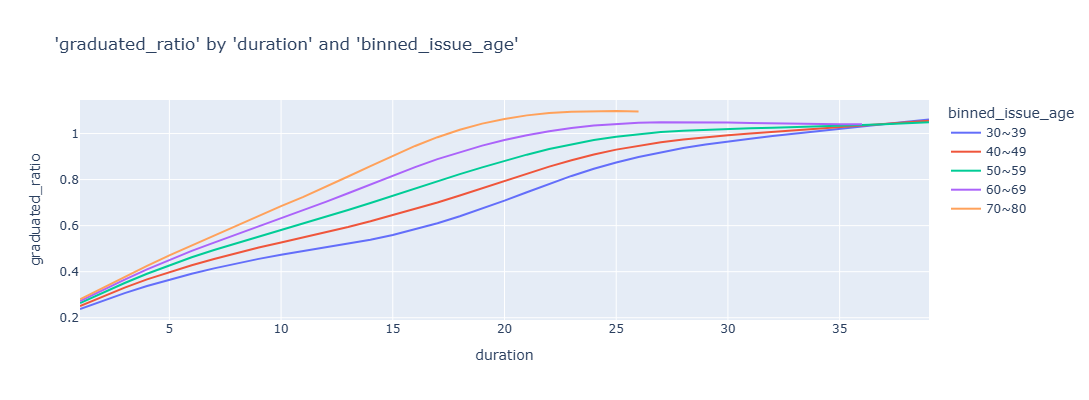

In [22]:
charters.chart(
    df=fig,
    x_axis="duration",
    y_axis="graduated_ratio",
    color="binned_issue_age",
    type="line",
    display=True,
)

# whl 1d

## UL

In [23]:
fig = charters.chart(
    df=grouped_df[
        (grouped_df["insurance_plan"] == "UL")
        & (grouped_df["duration"] <= 35)
        # & (grouped_df["issue_year"] >= 2000)
    ],
    x_axis="duration",
    y_axis="ratio",
    type="line",
    numerator="death_claim_amount",
    denominator="exp_amt_vbt15_ult",
    display=False,
)

 2025-12-08 23:36:57 | morai.experience.charters | INFO     | Calculating ratio using [death_claim_amount] and [exp_amt_vbt15_ult] 
['death_claim_amount', 'exp_amt_vbt15_ult']


In [24]:
fig["graduated_ratio"] = graduation.whl(
    rates=fig["ratio"],
    weights=fig["exp_amt_vbt15_ult"],
    horizontal_order=3,
    horizontal_lambda=100,
)

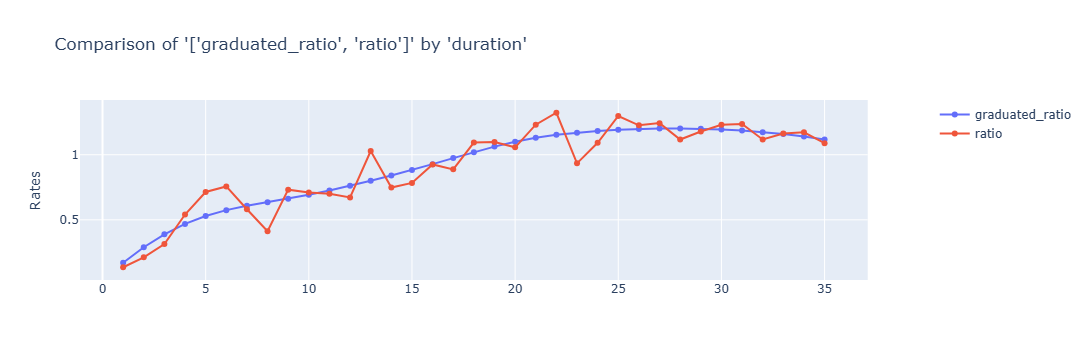

In [25]:
charters.compare_rates(df=fig, x_axis="duration", rates=["graduated_ratio", "ratio"])

In [26]:
# charters.chart(
#     df=fig,
#     x_axis="duration",
#     y_axis="death_claim_amount",
#     type="bar",
#     display=True,
# )

In [27]:
fig["insurance_plan"] = "UL"
duration_df = fig.copy()

## Term

In [28]:
fig = charters.chart(
    df=grouped_df[
        (grouped_df["insurance_plan"] == "Term")
        & (grouped_df["duration"] <= 20)
        # & (grouped_df["issue_year"] >= 2000)
    ],
    x_axis="duration",
    y_axis="ratio",
    type="line",
    numerator="death_claim_amount",
    denominator="exp_amt_vbt15_ult",
    display=False,
)

 2025-12-08 23:36:59 | morai.experience.charters | INFO     | Calculating ratio using [death_claim_amount] and [exp_amt_vbt15_ult] 
['death_claim_amount', 'exp_amt_vbt15_ult']


In [29]:
fig["graduated_ratio"] = graduation.whl(
    rates=fig["ratio"],
    weights=fig["exp_amt_vbt15_ult"],
    horizontal_order=3,
    horizontal_lambda=100,
)

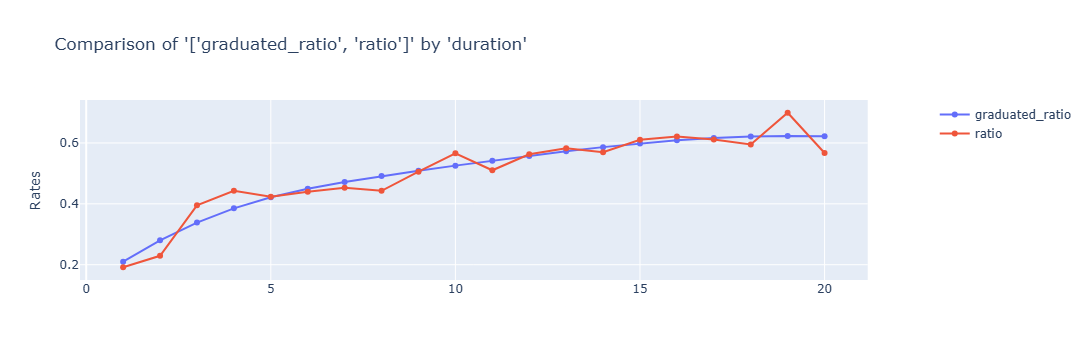

In [30]:
charters.compare_rates(df=fig, x_axis="duration", rates=["graduated_ratio", "ratio"])

In [31]:
fig["insurance_plan"] = "Term"
duration_df = pd.concat([fig, duration_df], axis=0, ignore_index=True)

## ULSG

In [32]:
fig = charters.chart(
    df=grouped_df[
        (grouped_df["insurance_plan"] == "ULSG")
        & (grouped_df["duration"] <= 18)
        # & (grouped_df["issue_year"] >= 2000)
    ],
    x_axis="duration",
    y_axis="ratio",
    type="line",
    numerator="death_claim_amount",
    denominator="exp_amt_vbt15_ult",
    display=False,
)

 2025-12-08 23:37:00 | morai.experience.charters | INFO     | Calculating ratio using [death_claim_amount] and [exp_amt_vbt15_ult] 
['death_claim_amount', 'exp_amt_vbt15_ult']


In [33]:
fig["graduated_ratio"] = graduation.whl(
    rates=fig["ratio"],
    weights=fig["exp_amt_vbt15_ult"],
    horizontal_order=3,
    horizontal_lambda=100,
)

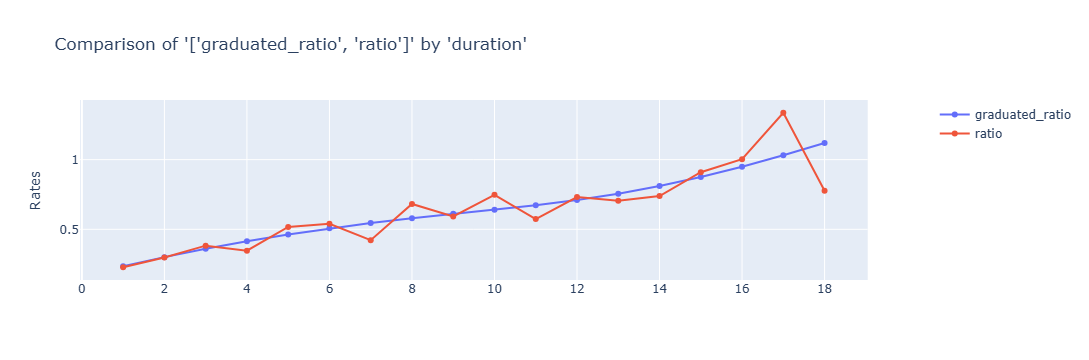

In [34]:
charters.compare_rates(df=fig, x_axis="duration", rates=["graduated_ratio", "ratio"])

In [35]:
fig["insurance_plan"] = "ULSG"
duration_df = pd.concat([fig, duration_df], axis=0, ignore_index=True)

## Perm

In [36]:
fig = charters.chart(
    df=grouped_df[
        (grouped_df["insurance_plan"] == "Perm")
        & (grouped_df["duration"] <= 35)
        # & (grouped_df["issue_year"] >= 2000)
    ],
    x_axis="duration",
    y_axis="ratio",
    type="line",
    numerator="death_claim_amount",
    denominator="exp_amt_vbt15_ult",
    display=False,
)

 2025-12-08 23:37:02 | morai.experience.charters | INFO     | Calculating ratio using [death_claim_amount] and [exp_amt_vbt15_ult] 
['death_claim_amount', 'exp_amt_vbt15_ult']


In [37]:
fig["graduated_ratio"] = graduation.whl(
    rates=fig["ratio"],
    weights=fig["exp_amt_vbt15_ult"],
    horizontal_order=3,
    horizontal_lambda=100,
)

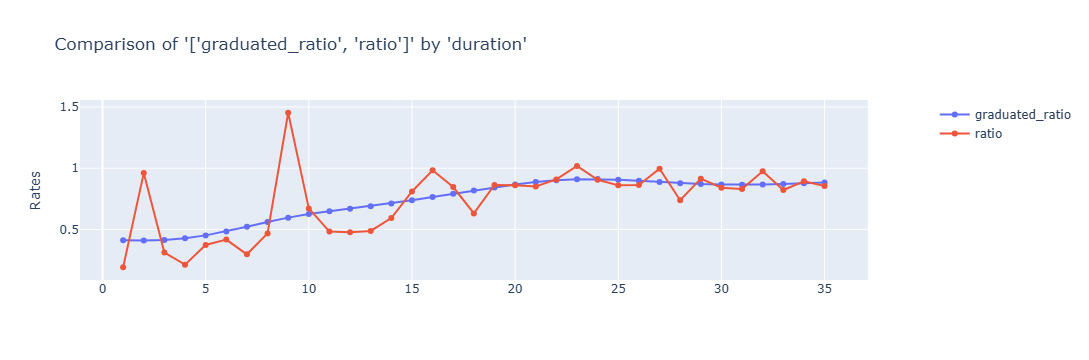

In [38]:
charters.compare_rates(df=fig, x_axis="duration", rates=["graduated_ratio", "ratio"])

In [39]:
fig["insurance_plan"] = "Perm"
duration_df = pd.concat([fig, duration_df], axis=0, ignore_index=True)

## All

graduated_ratio


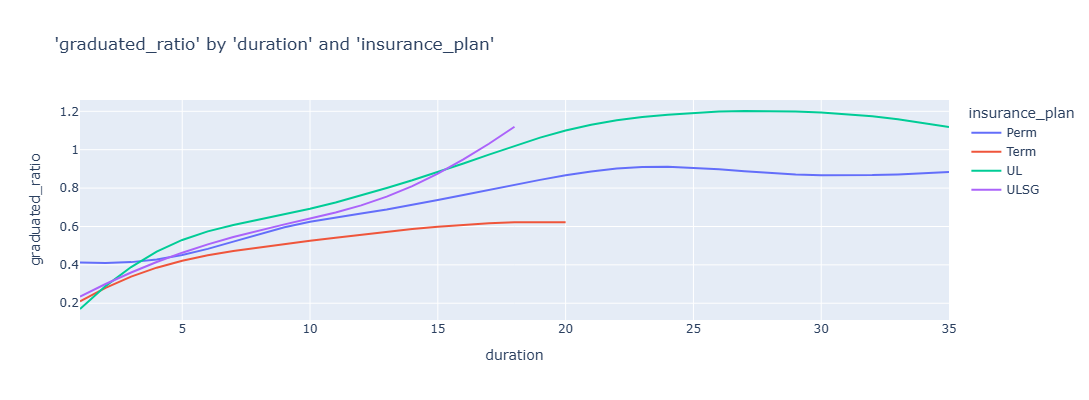

In [40]:
charters.chart(
    df=duration_df,
    x_axis="duration",
    y_axis="graduated_ratio",
    color="insurance_plan",
    type="line",
    display=True,
)

# Reload

In [198]:
importlib.reload(graduation)

<module 'morai.forecast.graduation' from 'C:\\Users\\johnk\\Desktop\\github\\morai\\morai\\forecast\\graduation.py'>